In [17]:
from langgraph.graph import StateGraph ,START ,END
from typing import TypedDict , Annotated , Literal
from dotenv import load_dotenv
from pydantic import BaseModel , Field
from langchain_groq import ChatGroq
import operator
from langchain_core.messages import SystemMessage , HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [2]:
load_dotenv()

True

In [7]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [6]:
class ChatState(TypedDict):

    messages : Annotated[list[BaseModel] , add_messages]

In [8]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm 
    response = llm.invoke(messages)

    # response store state
    return {'messages' :[response] }

In [18]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

# Add Node
graph.add_node('chat_node' , chat_node)

# Edges
graph.add_edge(START ,'chat_node')
graph.add_edge('chat_node' , END)

chatbot = graph.compile(checkpointer=checkpointer)

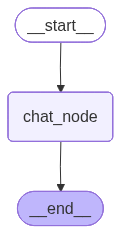

In [10]:
chatbot

In [15]:
initial_state = {
    'messages' : [HumanMessage(content='What is the capital of Maharashtra')]
}
chatbot.invoke(initial_state)['messages'][-1]

AIMessage(content='The capital of Maharashtra is Mumbai.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 41, 'total_tokens': 49, 'completion_time': 0.018739251, 'completion_tokens_details': None, 'prompt_time': 0.004694369, 'prompt_tokens_details': None, 'queue_time': 0.171374979, 'total_time': 0.02343362}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f6ec7-5b6a-7d80-b9d3-6eb9f2ec99eb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 8, 'total_tokens': 49})

In [ ]:
thread_id = '1'

while True:

    user_message = input('Type Query : ')
    print('User:' , user_message)

    if user_message.strip().lower() in ['exit' , 'quit' , 'bye']:
        break

    config = {'configurable' : {'thread_id':thread_id }}

    response = chatbot.invoke({'messages' : [HumanMessage(content=user_message)]} , config=config)
 
    print ('AI : ' , response['messages'][-1].content)

User: Hi
AI :  It's nice to meet you. Is there something I can help you with or would you like to chat?
User: My name is Parth
AI :  Nice to meet you, Parth! How's your day going so far? Is there something on your mind that you'd like to talk about, or would you like some recommendations or assistance with something? I'm all ears!
User: what is my name
AI :  Your name is Parth.
User: Add 2 and 3 
AI :  2 + 3 = 5
User: now add 25 to the result
AI :  We had 5 as the previous result. Now, let's add 25 to it:

5 + 25 = 30
User: bye


In [21]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='11bbc046-be35-4b41-8122-6bedda646dbe'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.050120627, 'completion_tokens_details': None, 'prompt_time': 0.005309546, 'prompt_tokens_details': None, 'queue_time': 0.058857264, 'total_time': 0.055430173}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f6edd-77f8-7652-a379-26a905c9fb5f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59}), HumanMessage(content='My name is Parth', additional_kwargs={}, response_metadata={}, id